In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport


C:\Users\goatf\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
movie_data = pd.read_csv('../movies.csv',index_col=0)

In [3]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7545 entries, 0 to 7544
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   MovieID       7431 non-null   object
 1   Title         7431 non-null   object
 2   MPAA Rating   7143 non-null   object
 3   Budget        7142 non-null   object
 4   Gross         2816 non-null   object
 5   Release Date  2570 non-null   object
 6   Genre         3055 non-null   object
 7   Runtime       1683 non-null   object
 8   Rating        1077 non-null   object
 9   Rating Count  509 non-null    object
 10  Summary       496 non-null    object
dtypes: object(11)
memory usage: 707.3+ KB


In [4]:
movie_data = movie_data.reset_index(drop=True)
movie_data.head()

,MovieID,Title,MPAA Rating,Budget,Gross,Release Date,Genre,Runtime,Rating,Rating Count,Summary
0,1,Look Who's Talking,PG-13,7500000,296000000,1989-10-12,Romance,93,5.9,73638,"After a single, career-minded woman is left on..."
1,2,Driving Miss Daisy,PG,7500000,145793296,1989-12-13,Comedy,99,7.4,91075,An old Jewish woman and her African-American c...
2,3,Turner & Hooch,PG,13000000,71079915,1989-07-28,Crime,100,7.2,91415,"Det. Scott Turner (Tom Hanks) is an uptight, b..."
3,4,Born on the Fourth of July,R,14000000,161001698,1989-12-20,War,145,7.2,91415,The biography of Ron Kovic. Paralyzed in the V...
4,5,Field of Dreams,PG,15000000,84431625,1989-04-21,Drama,107,7.5,101702,"An Iowa corn farmer, hearing voices, interpret..."


In [5]:
movie_data['MovieID']

0         1
1         2
2         3
3         4
4         5
       ... 
7540    NaN
7541    NaN
7542    NaN
7543    NaN
7544    NaN
Name: MovieID, Length: 7545, dtype: object

In [6]:
# 'MovieID' is just a number based on row and we don't need it
# There are also lots of null rows
movie_df = movie_data.drop(['MovieID'], axis=1)

In [7]:
movie_df.head()


,Title,MPAA Rating,Budget,Gross,Release Date,Genre,Runtime,Rating,Rating Count,Summary
0,Look Who's Talking,PG-13,7500000,296000000,1989-10-12,Romance,93,5.9,73638,"After a single, career-minded woman is left on..."
1,Driving Miss Daisy,PG,7500000,145793296,1989-12-13,Comedy,99,7.4,91075,An old Jewish woman and her African-American c...
2,Turner & Hooch,PG,13000000,71079915,1989-07-28,Crime,100,7.2,91415,"Det. Scott Turner (Tom Hanks) is an uptight, b..."
3,Born on the Fourth of July,R,14000000,161001698,1989-12-20,War,145,7.2,91415,The biography of Ron Kovic. Paralyzed in the V...
4,Field of Dreams,PG,15000000,84431625,1989-04-21,Drama,107,7.5,101702,"An Iowa corn farmer, hearing voices, interpret..."


In [8]:
movie_df.isnull().sum()

Title            114
MPAA Rating      402
Budget           403
Gross           4729
Release Date    4975
Genre           4490
Runtime         5862
Rating          6468
Rating Count    7036
Summary         7049
dtype: int64

In [9]:
movie_df.tail()

,Title,MPAA Rating,Budget,Gross,Release Date,Genre,Runtime,Rating,Rating Count,Summary
7540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7542,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7543,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7544,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
#Dropping rows that have no title
# if we don't have the title of the movie or release date we cant use it
# also many rows are null all the way across

movie_df1 =  movie_df.dropna(how='all',axis = 0)
movie_df1.reset_index()
movie_df1.tail()


,Title,MPAA Rating,Budget,Gross,Release Date,Genre,Runtime,Rating,Rating Count,Summary
7426,Nick Thurston,1987-12-07,San Francisco,USA,NaN,"Nick Thurston was born in Oakland, California....",Male,NaN,NaN,NaN
7427,Chris Pratt,1979-06-21,Virginia,USA,74,Christopher Michael Pratt is an American film ...,Male,white,NaN,NaN
7428,Dave Bautista,1969-01-18,Washington,USA,74,"David Michael Bautista, Jr. was born on Januar...",Male,white,NaN,NaN
7429,Lee Pace,1979-03-25,Chickasha,USA,77,"In 2003, Lee Grinner Pace starred in the Sunda...",Male,white,NaN,NaN
7430,Karen Gillan,1987-11-28,Inverness,UK,61,Karen Sheila Gillan was born and raised in Inv...,Female,white,NaN,NaN


In [11]:
# many rows are actually just actors and not movies, those need removed,they don't have int in many coloumns
# It looks like the actdors have a city in the budget column instead of something numeric


movie_drop1 = movie_df1['Budget'].str.isnumeric() == True

In [12]:
#checking the non numeric data from the drop table

movie_df1[~movie_drop1].head()

,Title,MPAA Rating,Budget,Gross,Release Date,Genre,Runtime,Rating,Rating Count,Summary
510,ActorID,Character Name,creditOrder,pay,screentime,NaN,NaN,NaN,NaN,NaN
4830,Name,Date of Birth,Birth City,Birth Country,Height (Inches),Biography,Gender,Ethnicity,NetWorth,NaN
4831,John Travolta,1954-02-18,Englewood,USA,74,"John Joseph Travolta was born in Englewood, Ne...",Male,White,NaN,NaN
4832,Kirstie Alley,1951-01-12,Wichita,USA,67,NaN,Female,white,NaN,NaN
4833,Olympia Dukakis,1931-06-20,Lowell,USA,63,"Long a vital, respected lady of the classic an...",Female,white,NaN,NaN


In [13]:
#it looks like this data acutally has 3 tables, two are for actors and one is for movies
# the actors start after row 509. I already removed one actor table becuase they had null ratings
# Removing the nonnumeric strings should remove the rest of the actors actors

movie_df2 = movie_df1[movie_drop1]
movie_df2.tail()

,Title,MPAA Rating,Budget,Gross,Release Date,Genre,Runtime,Rating,Rating Count,Summary
4825,1857,Rocket,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4826,2599,Ronan,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4827,286,Yondu Udonta,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4828,2600,Nebula,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4829,1433,Korath,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
#more actors who have no 'Gross' Value, and we need a 'Gross' value for analysis
movie_df2 = movie_df2.dropna(subset = 'Gross')

In [15]:
# need a Release Date for data analysis, and it looks like the NaN are more actors

movie_df2 = movie_df2.dropna(subset = 'Release Date')

In [16]:
movie_df2.reset_index(drop=True)

,Title,MPAA Rating,Budget,Gross,Release Date,Genre,Runtime,Rating,Rating Count,Summary
0,Look Who's Talking,PG-13,7500000,296000000,1989-10-12,Romance,93,5.9,73638,"After a single, career-minded woman is left on..."
1,Driving Miss Daisy,PG,7500000,145793296,1989-12-13,Comedy,99,7.4,91075,An old Jewish woman and her African-American c...
2,Turner & Hooch,PG,13000000,71079915,1989-07-28,Crime,100,7.2,91415,"Det. Scott Turner (Tom Hanks) is an uptight, b..."
3,Born on the Fourth of July,R,14000000,161001698,1989-12-20,War,145,7.2,91415,The biography of Ron Kovic. Paralyzed in the V...
4,Field of Dreams,PG,15000000,84431625,1989-04-21,Drama,107,7.5,101702,"An Iowa corn farmer, hearing voices, interpret..."
...,...,...,...,...,...,...,...,...,...,...
505,Big Hero 6,PG,165000000,652105443,2014-10-24,Animation,102,7.8,380953,The special bond that develops between plus-si...
506,Interstellar,PG-13,165000000,675120017,2014-11-05,Science Fiction,169,8.6,1343549,A team of explorers travel through a wormhole ...
507,Captain America: The Winter Soldier,PG-13,170000000,714766572,2014-03-20,Action,136,7.7,685903,As Steve Rogers struggles to embrace his role ...
508,Dawn of the Planet of the Apes,PG-13,170000000,710644566,2014-06-26,Science Fiction,130,7.6,395425,A growing nation of genetically evolved apes l...


the movie table now stops at row 510 which is where the actor tables started.

In [17]:
#Convert dates to dates

movie_df2['Release Date'] = pd.to_datetime(movie_df2['Release Date'])

In [18]:
# only null values in ratings and summaries which is ok
movie_df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 510 entries, 0 to 509
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Title         510 non-null    object        
 1   MPAA Rating   510 non-null    object        
 2   Budget        510 non-null    object        
 3   Gross         510 non-null    object        
 4   Release Date  510 non-null    datetime64[ns]
 5   Genre         510 non-null    object        
 6   Runtime       510 non-null    object        
 7   Rating        508 non-null    object        
 8   Rating Count  508 non-null    object        
 9   Summary       496 non-null    object        
dtypes: datetime64[ns](1), object(9)
memory usage: 43.8+ KB


In [19]:
# all The data types should be floats or intigers

movie_df2[['Gross','Budget','Runtime','Rating','Rating Count']] = movie_df2[['Gross','Budget','Runtime','Rating','Rating Count']].apply(pd.to_numeric, errors='coerce')


In [20]:
movie_df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 510 entries, 0 to 509
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Title         510 non-null    object        
 1   MPAA Rating   510 non-null    object        
 2   Budget        510 non-null    int64         
 3   Gross         510 non-null    int64         
 4   Release Date  510 non-null    datetime64[ns]
 5   Genre         510 non-null    object        
 6   Runtime       510 non-null    int64         
 7   Rating        508 non-null    float64       
 8   Rating Count  508 non-null    float64       
 9   Summary       496 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(4)
memory usage: 43.8+ KB


All the numbers are numbers or dates

In [21]:
#the two null values for 'Ratings' and the two for nulls 'Rating Count' are all found in the following rows
# the movies can be removed due to lack of data.

movie_df2[movie_df2['Rating'].isna()]

,Title,MPAA Rating,Budget,Gross,Release Date,Genre,Runtime,Rating,Rating Count,Summary
486,Fast & Furious 6,PG-13,160000000,788679850,2013-05-06,Action,130,NaN,NaN,NaN
489,Oz: The Great and Powerful,PG,200000000,491868548,2013-03-07,Drama,130,NaN,NaN,NaN


In [22]:
movie_df2 = movie_df2.dropna(subset = 'Rating')

In [23]:
#they are gone

movie_df2.loc[486:489]

,Title,MPAA Rating,Budget,Gross,Release Date,Genre,Runtime,Rating,Rating Count,Summary
487,Thor: The Dark World,PG-13,170000000,644571402,2013-10-29,Action,112,6.9,556094.0,When the Dark Elves attempt to plunge the univ...
488,Star Trek Into Darkness,PG-13,190000000,467365246,2013-05-05,Science Fiction,132,7.7,449458.0,After the crew of the Enterprise find an unsto...


In [24]:
#a new column with gross profit should be made
movie_df2['Gross Profit'] = movie_df2['Gross']-movie_df2['Budget']

In [25]:
movie_df2.head()

,Title,MPAA Rating,Budget,Gross,Release Date,Genre,Runtime,Rating,Rating Count,Summary,Gross Profit
0,Look Who's Talking,PG-13,7500000,296000000,1989-10-12,Romance,93,5.9,73638.0,"After a single, career-minded woman is left on...",288500000
1,Driving Miss Daisy,PG,7500000,145793296,1989-12-13,Comedy,99,7.4,91075.0,An old Jewish woman and her African-American c...,138293296
2,Turner & Hooch,PG,13000000,71079915,1989-07-28,Crime,100,7.2,91415.0,"Det. Scott Turner (Tom Hanks) is an uptight, b...",58079915
3,Born on the Fourth of July,R,14000000,161001698,1989-12-20,War,145,7.2,91415.0,The biography of Ron Kovic. Paralyzed in the V...,147001698
4,Field of Dreams,PG,15000000,84431625,1989-04-21,Drama,107,7.5,101702.0,"An Iowa corn farmer, hearing voices, interpret...",69431625


In [26]:
# want to see if there are any duplicate movies that should be removed

movie_df2[['Title']].nunique()

Title    505
dtype: int64

There are duplicate movies based on the row count

In [27]:
movie_df2[movie_df2.duplicated(subset=['Title'],keep=False)]

,Title,MPAA Rating,Budget,Gross,Release Date,Genre,Runtime,Rating,Rating Count,Summary,Gross Profit
21,Teenage Mutant Ninja Turtles,PG,13500000,202000000,1990-03-30,Action,93,6.8,79806.0,Four teenage mutant ninja turtles emerge from ...,188500000
98,Jurassic Park III,PG-13,93000000,368800000,2001-07-16,Thriller,92,8.9,1690474.0,A decidedly odd couple with ulterior motives ...,275800000
195,Godzilla,PG-13,130000000,379014294,1998-05-20,Thriller,139,5.4,174600.0,"A giant, reptilian monster surfaces, leaving d...",249014294
249,Jurassic Park III,PG-13,93000000,368780809,2001-07-18,Adventure,92,5.9,280110.0,A decidedly odd couple with ulterior motives c...,275780809
501,Teenage Mutant Ninja Turtles,PG-13,125000000,477200000,2014-08-07,Action,101,5.8,194073.0,"When a kingpin threatens New York City, a grou...",352200000
504,Godzilla,PG-13,160000000,529076069,2014-05-14,Thriller,123,6.4,359438.0,The world is beset by the appearance of monstr...,369076069


In [28]:
# only Jurassic park III is truly duplicated, the other 2 are remakes
# IMBD has the rating of 5.9, so I'm going to keep that one and remove the other
# Based on google, the release date of 2001-07-16 is also not accurate, both Jurassic parks also have the same Gross,
# keeping both rows would duplicate the data
# however, I can average the rating with row 249 that I am keeping.

movie_df2.loc[249,'Rating'] = (movie_df2.loc[98,'Rating'] + movie_df2.loc[249,'Rating'])/2

In [29]:
movie_df2.loc[249,'Rating Count'] = (movie_df2.loc[98,'Rating Count'] + movie_df2.loc[249,'Rating Count'])/2

In [30]:
#drop the duplicate row

movie_df2 = movie_df2.drop(98)

In [31]:
movie_df2[movie_df2.duplicated(subset=['Title'],keep=False)]

,Title,MPAA Rating,Budget,Gross,Release Date,Genre,Runtime,Rating,Rating Count,Summary,Gross Profit
21,Teenage Mutant Ninja Turtles,PG,13500000,202000000,1990-03-30,Action,93,6.8,79806.0,Four teenage mutant ninja turtles emerge from ...,188500000
195,Godzilla,PG-13,130000000,379014294,1998-05-20,Thriller,139,5.4,174600.0,"A giant, reptilian monster surfaces, leaving d...",249014294
501,Teenage Mutant Ninja Turtles,PG-13,125000000,477200000,2014-08-07,Action,101,5.8,194073.0,"When a kingpin threatens New York City, a grou...",352200000
504,Godzilla,PG-13,160000000,529076069,2014-05-14,Thriller,123,6.4,359438.0,The world is beset by the appearance of monstr...,369076069


In [32]:
movie_df2[['MPAA Rating']].nunique()

MPAA Rating    4
dtype: int64

In [33]:
movie_df2[['Genre']].nunique()

Genre    16
dtype: int64

In [34]:
movie_df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 507 entries, 0 to 509
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Title         507 non-null    object        
 1   MPAA Rating   507 non-null    object        
 2   Budget        507 non-null    int64         
 3   Gross         507 non-null    int64         
 4   Release Date  507 non-null    datetime64[ns]
 5   Genre         507 non-null    object        
 6   Runtime       507 non-null    int64         
 7   Rating        507 non-null    float64       
 8   Rating Count  507 non-null    float64       
 9   Summary       495 non-null    object        
 10  Gross Profit  507 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(4), object(4)
memory usage: 47.5+ KB


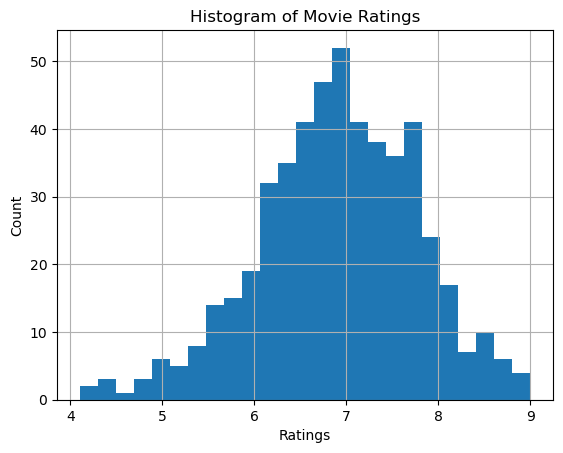

In [35]:
# see the ratings

movie_df2.Rating.hist(bins=25)
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.title('Histogram of Movie Ratings');

This histogram shows that the move ratings have a rather nice bell curve reflecting clean data without outliers.

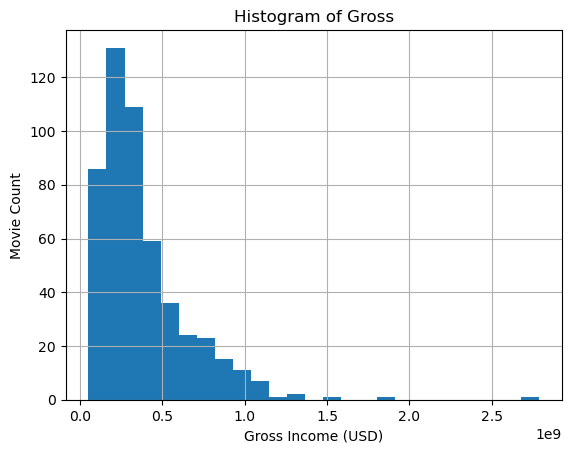

In [36]:
#the ratings have a nice curve to them, and they are all between 4 and 9. 

movie_df2.Gross.hist(bins=25)
plt.xlabel('Gross Income (USD)')
plt.ylabel('Movie Count')
plt.title('Histogram of Gross');

We can see that The movie gross income is scewed to the right in a uniform pattern with a few outliers.

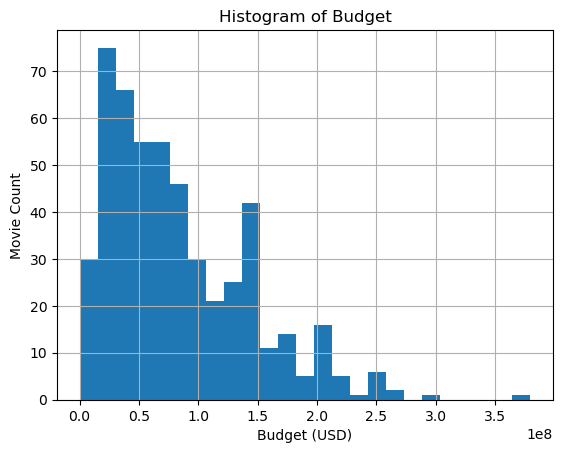

In [37]:
movie_df2.Budget.hist(bins=25)
plt.xlabel('Budget (USD)')
plt.ylabel('Movie Count')
plt.title('Histogram of Budget');

The movie budges are also scewed to the right, but the data appears clean.

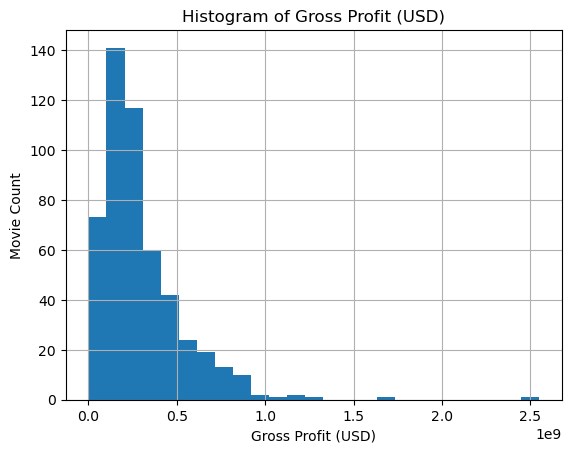

In [38]:
movie_df2['Gross Profit'].hist(bins=25)
plt.xlabel('Gross Profit (USD)')
plt.ylabel('Movie Count')
plt.title('Histogram of Gross Profit (USD)');

The Gross Profit also scews to the right like the other catagories. 

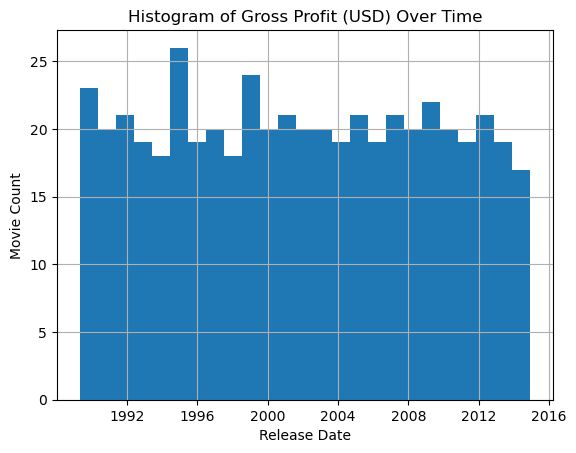

In [39]:
#checking to see that the movies in the database are spread evenly over time.

movie_df2['Release Date'].hist(bins=25)
plt.xlabel('Release Date')
plt.ylabel('Movie Count')
plt.title('Histogram of Gross Profit (USD) Over Time');

The data base seems to be equally spread across 20 years, with 17 to 25 movies per year.

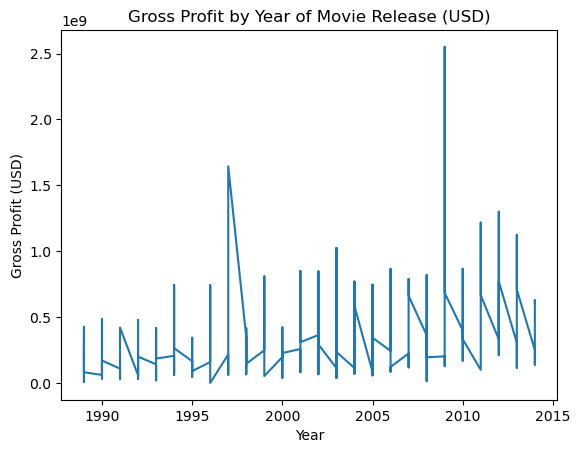

In [40]:
plt.plot(movie_df2['Release Date'].dt.year, movie_df2['Gross Profit'])
plt.xlabel('Year')
plt.ylabel('Gross Profit (USD)')
plt.title('Gross Profit by Year of Movie Release (USD)');

this shows a graph of Gross Profit over time. We can see our two outliers, Titanic and Avatar. But they are acurate numbers to keep. All of the plots of the data show the outliers, but otherwise have nice normal curves on them.

In this notebook, 1000 rows were removed from the original data. Those rows contained null values, or were of actors and not movies. Also two movies were removed because they had no Rating or Rating count. A duplicate entry for Jurassic Park III was averaged. 

The data was looked at graphicly to see if there were any outliers, or other abnormalities. There are two, Titanic and Avatar, but we know those values are accurate.

There are 4 rating levels
there are 16 genres
also a gross profits column was added to the table.

Based on the graphs all currencies appear to be USD becasue there are no outliers.

In [41]:
# save the data to a new csv file
movie_df2.to_csv('../data/Movies_clean.csv', index=False)